## **시계열 트랜스포머 모델**

* 런타임 환경이 GPU로 설정되지 않으면 시간이 많이 걸릴수 있습니다.


📌[실습 04-23] 라이브러리 불러오기

In [1]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 106.9 MB/s eta 0:00:00


In [2]:
!wget https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
from mini_transformers import TextEmbedding, PatchEmbedding, TimeSeriesEmbedding, TransformerBlock

--2026-08-02 05:09:29--  https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7391 (7.2K) [text/plain]
Saving to: ‘mini_transformers.py’

mini_transformers.p 100%[===================>]   7.22K  --.-KB/s    in 0s      

2026-08-02 05:09:29 (87.2 MB/s) - ‘mini_transformers.py’ saved [7391/7391]



### 실습 데이터 불러오기
* 어떤 브랜드의 일별 매출과 감성지수


In [3]:
df=pd.read_csv("감성_매출.csv", encoding="cp949").set_index(["Date"])
df

,Sentiment,Sales
Date,,
2023-01-01,0.52,349.19
2023-01-02,0.52,359.26
2023-01-03,0.59,364.37
2023-01-04,0.66,353.15
2023-01-05,0.60,356.72
...,...,...
2025-12-26,0.63,472.02
2025-12-27,0.61,495.45
2025-12-28,0.62,485.57


# 데이터 전처리

In [4]:
vars=df[["Sentiment", "Sales"]]  # 분석 대상 변수 설정
num_vars=vars.shape[1]     # 변수의 개수
var_names=vars.columns
print("변수의 개수=", num_vars); print()

# 스케일 정규화
scaler_mm=MinMaxScaler()
data = scaler_mm.fit_transform(vars)

# 입력과 타깃 변수 생성
seq_length = 120
print("입력 시퀀스의 길이= ", seq_length); print()
X, y = [], []
for i in range(len(data) - seq_length):
    X.append(data[i:i + seq_length,:])
    y.append(data[i + seq_length,:])
X=np.array(X); y=np.array(y)
print("전체 입력 데이터의 차원:", X.shape) # (샘플 수, 시퀀스 길이, 입력 변수의 수)
print("전체 타깃 데이터의 차원:", y.shape) # (샘플 수, 시퀀스 길이, 타깃 변수의 수)
print()

# 데이터 분할(시간 기준)
split=int(len(X)*0.8)
x_train=X[:split]; x_test=X[split:]
y_train=y[:split]; y_test=y[split:]

print("훈련용 입력 데이터 차원:", x_train.shape)
print("훈련용 타깃 데이터 차원:", y_train.shape)
print()
print("검증용 입력 데이터 차원:", x_test.shape)
print("검증용 타깃 데이터 차원:", y_test.shape)


변수의 개수= 2

입력 시퀀스의 길이=  120

전체 입력 데이터의 차원: (975, 120, 2)
전체 타깃 데이터의 차원: (975, 2)

훈련용 입력 데이터 차원: (780, 120, 2)
훈련용 타깃 데이터 차원: (780, 2)

검증용 입력 데이터 차원: (195, 120, 2)
검증용 타깃 데이터 차원: (195, 2)


# 트랜스포머 모델 설정 및 학습

In [ ]:
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# 하이퍼 파라미터
embed_dim=64
num_heads=4
patch_size=10  # 패치의 크기
input_shape=x_train[0].shape

# 트랜스포머 모델 설정
model=Sequential([
      Input(shape=input_shape),
      TimeSeriesEmbedding(seq_length, patch_size, embed_dim),
      TransformerBlock(num_heads, use_causal_mask=True),
      TransformerBlock(num_heads, use_causal_mask=True),
      TransformerBlock(num_heads, use_causal_mask=True, return_sequences=False),

      Dense(128, activation='relu'),
      Dropout(0.3),
      Dense(num_vars, activation='linear')
      ])

early_stop= EarlyStopping(monitor='val_loss',
    patience=20, restore_best_weights=True)

model.compile(loss="mse", optimizer="adam", metrics=['mae'])

history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
    epochs=500, batch_size=32, callbacks=[early_stop])

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 518ms/step - loss: 0.4399 - mae: 0.4670 - val_loss: 0.0696 - val_mae: 0.2029
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0647 - mae: 0.1989 - val_loss: 0.0306 - val_mae: 0.1383
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0321 - mae: 0.1406 - val_loss: 0.0300 - val_mae: 0.1367
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0299 - mae: 0.1340 - val_loss: 0.0243 - val_mae: 0.1197
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0269 - mae: 0.1286 - val_loss: 0.0138 - val_mae: 0.0856
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0251 - mae: 0.1246 - val_loss: 0.0226 - val_mae: 0.1185
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0239 - mae: 0.1213 - val_loss: 0.0255 - val_mae: 0.1261
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0228 - mae: 0.1178 - val_loss: 0.0176 - val_mae: 0.1008
Epoch 9/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 

# 예측 정확도 시각화

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step


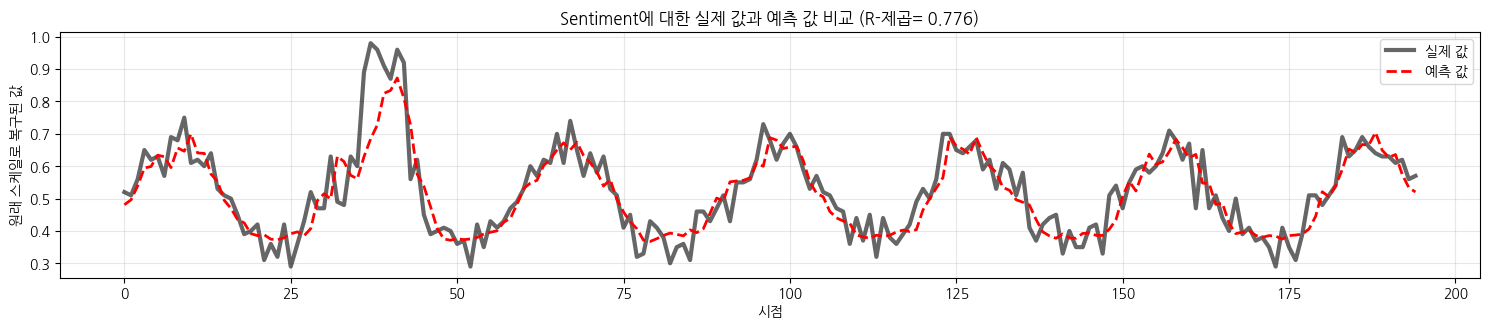

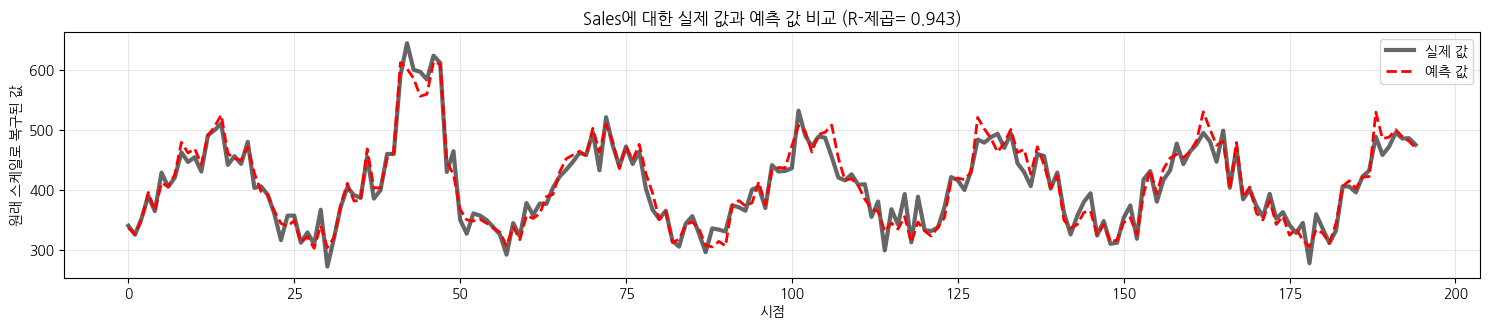

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# 테스트 데이터에 대한 예측 수행
y_pred = model.predict(x_test)

# 스케일 복구
y_test_inverse = scaler_mm.inverse_transform(y_test)
y_pred_inverse = scaler_mm.inverse_transform(y_pred)

# R 제곱 계산
R=[]
for i in range(num_vars):
  R.append(r2_score(y_test[:, i], y_pred[:,i]))

# 시각화 (변수별로 서브플롯 생성)
for i in range(num_vars):
  plt.figure(figsize=(15, 6))
  plt.subplot(num_vars, 1, i+1)
  plt.plot(y_test_inverse[:, i], label='실제 값', color='black', linewidth=3, alpha=0.6)
  plt.plot(y_pred_inverse[:, i], label='예측 값', color='red', linestyle='--', linewidth=2)
  plt.title(f"{var_names[i]}에 대한 실제 값과 예측 값 비교 (R-제곱={R[i]: .3f})")
  plt.xlabel("시점")
  plt.ylabel("원래 스케일로 복구된 값")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.tight_layout(); plt.show()